# Customer Retention & Churn Analysis
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
data=pd.read_csv(r"C:\Users\snehi\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Data Understanding and Exploration

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print(data["TotalCharges"].value_counts().tail())

TotalCharges
6849.4    1
692.35    1
130.15    1
3211.9    1
6844.5    1
Name: count, dtype: int64


In [26]:
print((data["TotalCharges"] == " ").sum())

0


In [27]:
print(data["TotalCharges"].isnull().sum())

11


In [28]:

print(data.shape)
print(data["TotalCharges"].dtype)

(7043, 21)
float64


In [29]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [30]:
print(data["TotalCharges"].dtype)

float64


In [31]:
print(data["TotalCharges"].isnull().sum())

11


In [32]:
print(data[data["TotalCharges"].isnull()][["customerID", "tenure", "TotalCharges", "Churn"]])

      customerID  tenure  TotalCharges Churn
488   4472-LVYGI       0           NaN    No
753   3115-CZMZD       0           NaN    No
936   5709-LVOEQ       0           NaN    No
1082  4367-NUYAO       0           NaN    No
1340  1371-DWPAZ       0           NaN    No
3331  7644-OMVMY       0           NaN    No
3826  3213-VVOLG       0           NaN    No
4380  2520-SGTTA       0           NaN    No
5218  2923-ARZLG       0           NaN    No
6670  4075-WKNIU       0           NaN    No
6754  2775-SEFEE       0           NaN    No


In [33]:
data.shape

(7043, 21)

## 5. Overall Customer Churn Analysis

In [34]:
print(data["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [35]:
print(data["Churn"].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


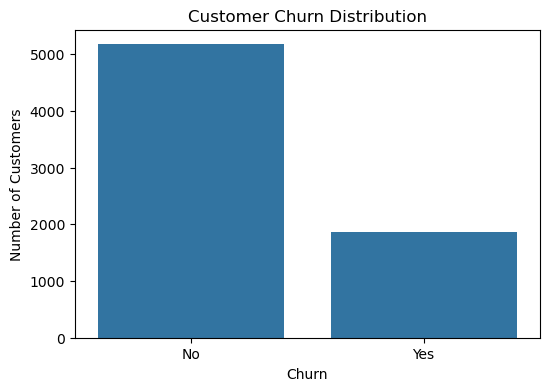

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=data)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 6. Churn Rate by Contract Type

In [43]:
total_customers=len(data)
churned_customers=(data["Churn"]=="Yes").sum()
churned_rate=(churned_customers/total_customers)*100
print("Total Customers:", total_customers)
print("Churned customers:",churned_customers)
print("Churned rate:",round(churned_rate,2),"%")


Total Customers: 7043
Churned customers: 1869
Churned rate: 26.54 %


In [44]:
contract_churn=pd.crosstab(data["Contract"],data["Churn"])
print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [47]:
contract_churn_rate = pd.crosstab(
    data["Contract"],
    data["Churn"],
    normalize="index"
) * 100

contract_churn_rate = contract_churn_rate.round(2)

print(contract_churn_rate)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [48]:
contract_plot = contract_churn_rate.reset_index()

print(contract_plot)

Churn        Contract     No    Yes
0      Month-to-month  57.29  42.71
1            One year  88.73  11.27
2            Two year  97.17   2.83


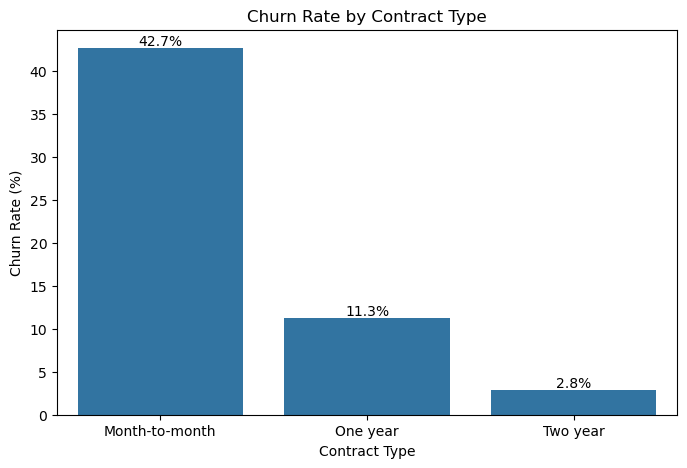

In [51]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Contract",
    y="Yes",
    data=contract_plot
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 7. Churn Rate by Tenure

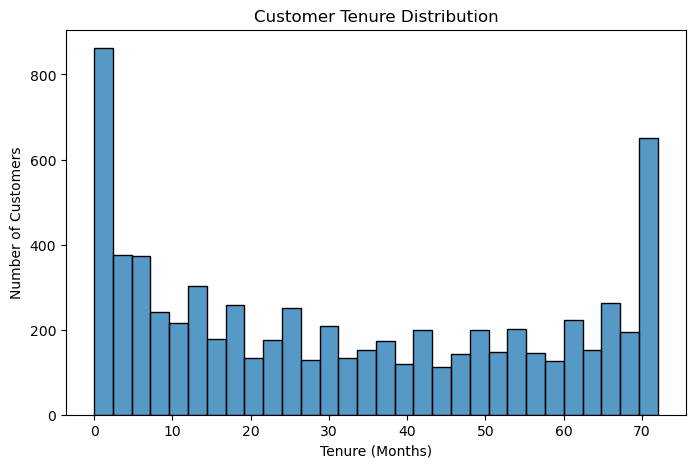

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(data=data, x="tenure", bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [53]:
print(data.groupby("Churn")["tenure"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


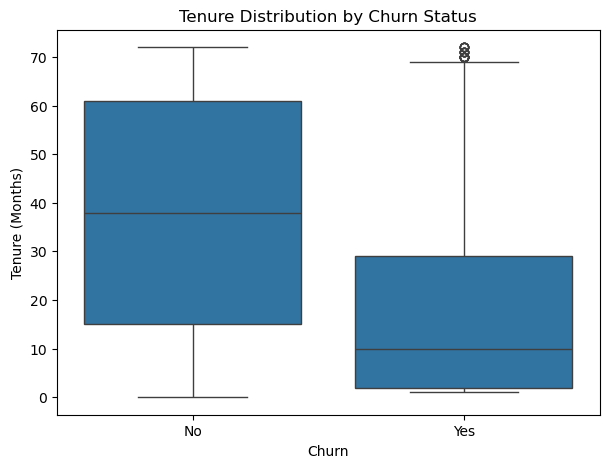

In [54]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="tenure", data=data)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## 8. Churn Rate by Monthly Charges

In [55]:
print(data.groupby("Churn")["tenure"].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [57]:
print(data.groupby("Churn")["MonthlyCharges"].mean())

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


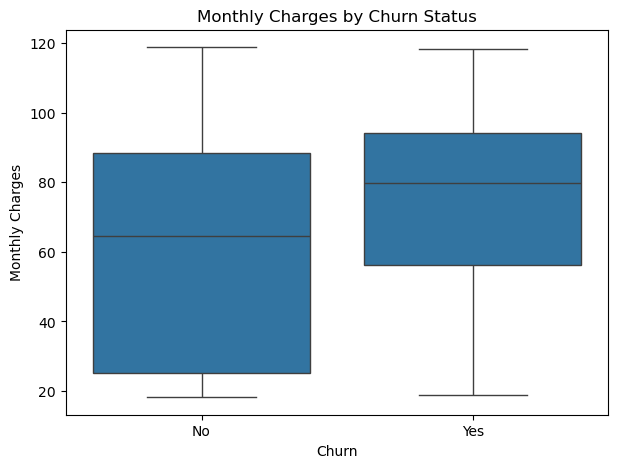

In [58]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=data)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## 9. Churn Rate by Payment Method

In [59]:
payment_churn = pd.crosstab(
    data["PaymentMethod"],
    data["Churn"],
    normalize="index"
) * 100

payment_churn = payment_churn.round(2)

print(payment_churn)

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


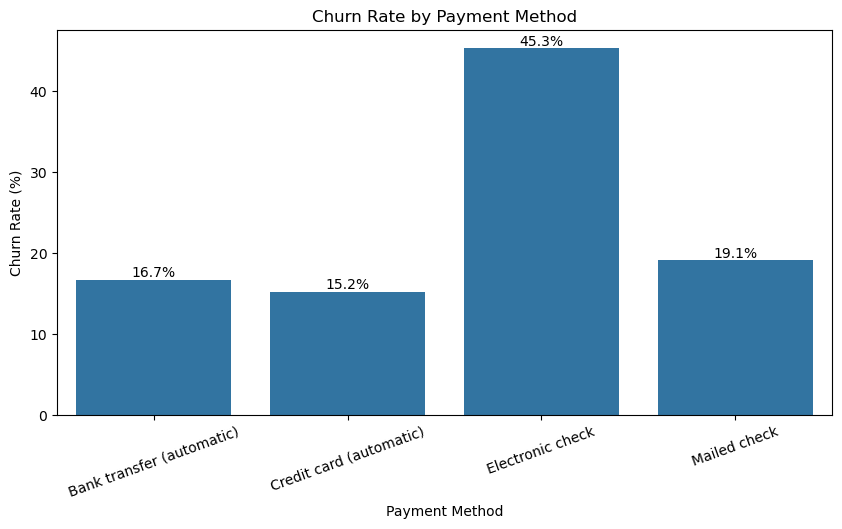

In [60]:
payment_plot = payment_churn.reset_index()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x="PaymentMethod",
    y="Yes",
    data=payment_plot
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 10. Churn Rate by Internet Service

In [62]:
internet_churn = pd.crosstab(
    data["InternetService"],
    data["Churn"],
    normalize="index"
) * 100

internet_churn = internet_churn.round(2)

print(internet_churn)

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


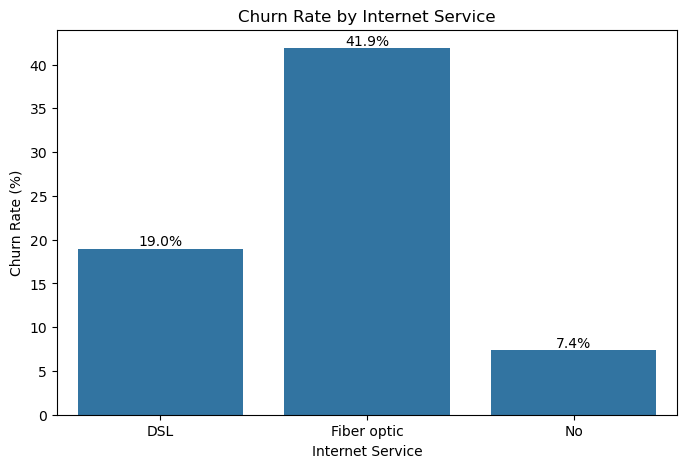

In [63]:
internet_plot = internet_churn.reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="InternetService",
    y="Yes",
    data=internet_plot
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 11. Churn Rate by Online Security

In [64]:
security_churn = pd.crosstab(
    data["OnlineSecurity"],
    data["Churn"],
    normalize="index"
) * 100

security_churn = security_churn.round(2)

print(security_churn)

Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


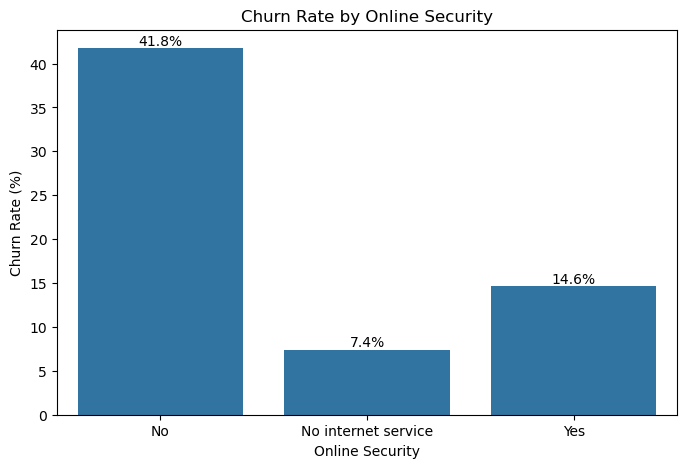

In [65]:
security_plot = security_churn.reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="OnlineSecurity",
    y="Yes",
    data=security_plot
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 12. Churn Rate by Tech Support

In [66]:
support_churn = pd.crosstab(
    data["TechSupport"],
    data["Churn"],
    normalize="index"
) * 100

support_churn = support_churn.round(2)

print(support_churn)

Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


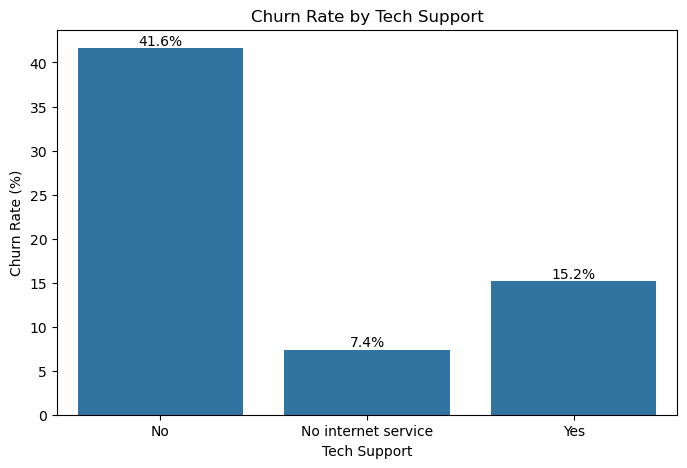

In [67]:
support_plot = support_churn.reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="TechSupport",
    y="Yes",
    data=support_plot
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

## 14. Retention Analysis by Customer Tenure

In [70]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    "0-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "61-72 months"
]

data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(data["TenureGroup"].value_counts().sort_index())

TenureGroup
0-12 months     2186
13-24 months    1024
25-36 months     832
37-48 months     762
49-60 months     832
61-72 months    1407
Name: count, dtype: int64


In [71]:
tenure_churn = pd.crosstab(
    data["TenureGroup"],
    data["Churn"],
    normalize="index"
) * 100

tenure_churn = tenure_churn.round(2)

print(tenure_churn)

Churn            No    Yes
TenureGroup               
0-12 months   52.56  47.44
13-24 months  71.29  28.71
25-36 months  78.37  21.63
37-48 months  80.97  19.03
49-60 months  85.58  14.42
61-72 months  93.39   6.61


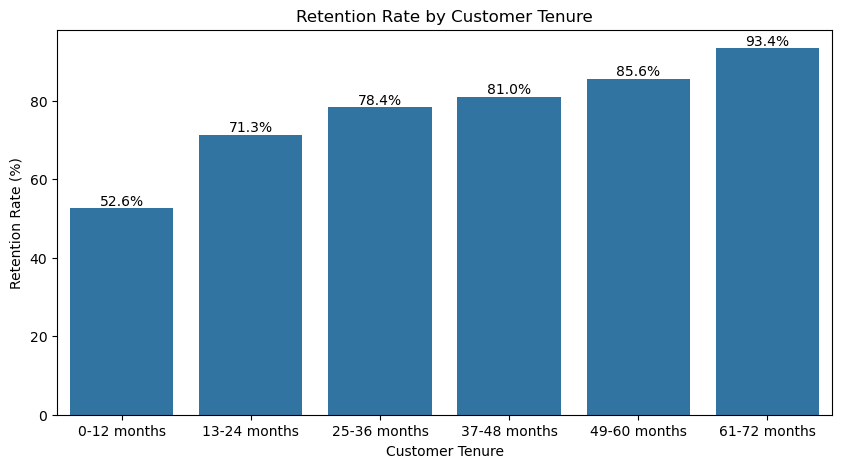

In [72]:
tenure_plot = tenure_churn.reset_index()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x="TenureGroup",
    y="No",
    data=tenure_plot
)

plt.title("Retention Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Retention Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [73]:
data_charges = data.dropna(subset=["TotalCharges"])

print(data_charges.groupby("Churn")["TotalCharges"].mean())

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


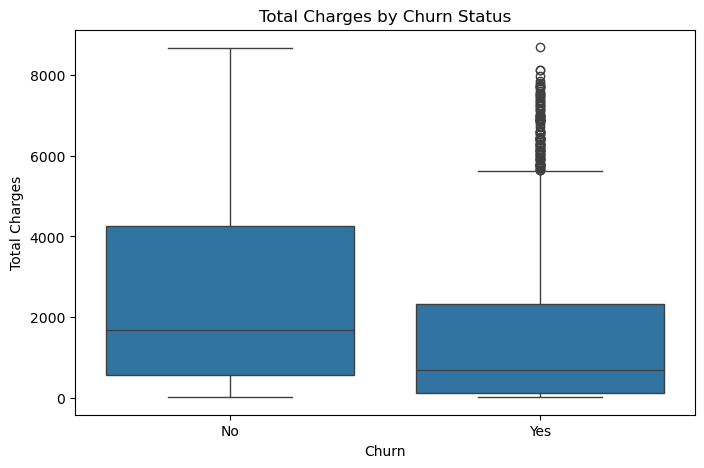

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=data_charges
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

## 15. Customer Lifetime Analysis

In [78]:
print("Overall Churn Rate:")
print(round(churned_rate, 2), "%")

print("\nChurn Rate by Contract:")
print(contract_churn_rate["Yes"])

print("\nAverage Tenure by Churn:")
print(data.groupby("Churn")["tenure"].mean())

print("\nChurn Rate by Internet Service:")
print(internet_churn["Yes"])

print("\nChurn Rate by Online Security:")
print(security_churn["Yes"])

print("\nChurn Rate by Tech Support:")
print(support_churn["Yes"])

print("\nAverage Total Charges by Churn:")
print(data_charges.groupby("Churn")["TotalCharges"].mean())

Overall Churn Rate:
26.54 %

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

Average Tenure by Churn:
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

Churn Rate by Internet Service:
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Yes, dtype: float64

Churn Rate by Online Security:
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Yes, dtype: float64

Churn Rate by Tech Support:
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Yes, dtype: float64

Average Total Charges by Churn:
Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


In [85]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Avg Tenure - Churned",
        "Avg Tenure - Retained",
        "Avg Total Charges - Churned",
        "Avg Total Charges - Retained"
    ],
    
    "Value": [
        len(data),
        (data["Churn"] == "Yes").sum(),
        round((data["Churn"] == "Yes").mean() * 100, 2),
        round(data[data["Churn"] == "Yes"]["tenure"].mean(), 2),
        round(data[data["Churn"] == "No"]["tenure"].mean(), 2),
        round(data_charges[data_charges["Churn"] == "Yes"]["TotalCharges"].mean(), 2),
        round(data_charges[data_charges["Churn"] == "No"]["TotalCharges"].mean(), 2)
    ]
})

print(summary)

                         Metric    Value
0               Total Customers  7043.00
1             Churned Customers  1869.00
2            Overall Churn Rate    26.54
3          Avg Tenure - Churned    17.98
4         Avg Tenure - Retained    37.57
5   Avg Total Charges - Churned  1531.80
6  Avg Total Charges - Retained  2555.34


In [86]:
total_customers = len(data)

churned_customers = (data["Churn"] == "Yes").sum()

retained_customers = (data["Churn"] == "No").sum()

churn_rate = (churned_customers / total_customers) * 100

retention_rate = (retained_customers / total_customers) * 100

avg_tenure = data["tenure"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Retention Rate:", round(retention_rate, 2), "%")
print("Average Tenure:", round(avg_tenure, 2), "months")

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54 %
Retention Rate: 73.46 %
Average Tenure: 32.37 months


## 16. Key Findings

- The overall customer churn rate is approximately 26.54%, with 1,869 customers having churned out of 7,043 customers.

- Contract type is strongly associated with churn. Month-to-month customers have a churn rate of 42.7%, compared with 11.3% for one-year contracts and 2.8% for two-year contracts.

- Customers who churned had a lower average tenure of approximately 18.0 months, compared with 37.6 months for customers who remained.

- Retention varies across different customer tenure groups, indicating that customer retention changes as customers remain with the service for longer periods.

- Churn rates also vary across internet service types, payment methods, online security availability, and technical support availability.

- Total Charges provide a useful customer-lifetime spending measure in this dataset. However, they should be treated as a lifetime-spending proxy rather than a complete Customer Lifetime Value (CLV) calculation.

- The dataset does not contain an explicit churn-reason field. Therefore, the analysis identifies factors associated with churn rather than assigning specific reasons for why individual customers left.

## 17. Retention Recommendations

Based on the observed churn patterns, the following retention strategies are recommended:

1. **Focus on month-to-month customers**
   - Month-to-month customers show substantially higher observed churn than customers with longer-term contracts.
   - The company can consider targeted retention offers and incentives to encourage suitable customers to move to longer-term contracts.

2. **Strengthen early-stage customer retention**
   - Churned customers have a considerably lower average tenure than retained customers.
   - Early-tenure customers can be given onboarding support, service guidance, and periodic engagement to improve retention.

3. **Improve support and security offerings**
   - Churn rates differ between customers with and without technical support and online security.
   - The company can review these services and communicate their benefits more effectively to customers.

4. **Monitor high-churn customer segments**
   - Customer segments with higher observed churn should be monitored regularly.
   - Retention campaigns can be targeted toward these segments rather than applying the same strategy to every customer.

5. **Use customer lifetime information for retention planning**
   - Tenure and Total Charges can be monitored to identify customer lifetime patterns.
   - Customers at different stages of their relationship can receive different engagement and retention strategies.

6. **Use data-driven churn monitoring**
   - Churn rates should be tracked regularly across contract type, tenure, internet service, payment method, online security, and technical support.
   - This can help identify changes in customer retention patterns over time.

## 18. Conclusion

This analysis examined customer churn and retention patterns for the subscription-based customer dataset. The overall churn rate was approximately 26.54%, with 1,869 out of 7,043 customers having churned.

The analysis showed that churn varies across contract types, customer tenure, internet service, payment methods, online security, and technical support. Month-to-month customers had a substantially higher observed churn rate than customers with longer-term contracts, while churned customers had a lower average tenure than retained customers.

Tenure-based retention analysis provided insight into customer lifetime trends, while Total Charges were used as a proxy for accumulated customer spending. These findings can help identify customer segments that require greater retention attention.

Overall, the analysis provides a data-driven view of customer churn patterns and highlights areas where targeted retention strategies can be considered. Since the dataset does not include explicit customer-reported churn reasons, the findings represent observed associations rather than confirmed causes of churn.